Title: cluster_plt_only_VRES.ipynb

Purpose: Make a nice plot of the clusters with the new method

Author: Onno Nennecke on 15.06.2025 Modified: 16.05.2026

Input data: 

- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- PSL Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/

Output data:

- Cluster Plot: cluster_analysis_2x2, cluster_analysis_combined, cluster_analysis_combined_v2
    - This file lies here: /home/onennecke/Code/Figures/

In [ ]:
# Load libraries
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from datetime import datetime, timedelta
from matplotlib.patches import Patch
import cftime
import joblib
from scipy.spatial.distance import cdist



In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
def create_date_list(LEE_data, cluster_data):
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute all calendar dates in that interval (inclusive), wrapping across year-end
    if start > end, but explicitly skip any leap day (Feb 29).

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[str]: flat list of dates (YYYY-MM-DD) covering each event, without Feb 29.
    """
    # date_list = []
    records = []
    for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
        start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
        end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
        num_days = (end_date - start_date).days + 1
        for offset in range(num_days):
            current = start_date + timedelta(days=offset)
            if current.month == 2 and current.day == 29:
                continue
            # current64 = np.datetime64(current)  # now datetime64[ns]
            current_cf = cftime.DatetimeNoLeap(
                current.year,
                current.month,
                current.day
            )
            try:
                cluster = cluster_data.sel(
                    time=current_cf,
                    ESM_run=esm_run#,
                    # method="nearest"
                ).item()

            except Exception as e:
                print(
                    f"[WARN] Missing cluster for {current_cf} "
                    f"(ESM_run={esm_run}) → inserting NaN"
                )
                cluster = np.nan
            # cluster = cluster_data.sel(time=current_cf, ESM_run=esm_run).item()
            # cluster = cluster_data.sel(time=current64, ESM_run=esm_run).item()
            records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})
    return pd.DataFrame(records)



### Read LEE data

In [4]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')


In [5]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# If ESM_run contains 'CESM2_LE2-*' rename the ESM to 'CESM_LE'
# LEE_dat['ESM'] = LEE_dat.apply(lambda row: 'CESM_LE' if 'CESM2_LE2-' in row['ESM_run'] else row['ESM'], axis=1)
# LEE_7['ESM'] = LEE_7.apply(lambda row: 'CESM_LE' if 'CESM2_LE2-' in row['ESM_run'] else row['ESM'], axis=1)
# LEE_14['ESM'] = LEE_14.apply(lambda row: 'CESM_LE' if 'CESM2_LE2-' in row['ESM_run'] else row['ESM'], axis=1)


# Remove all events that start or end outside of October-March
LEE_dat = LEE_dat[((LEE_dat['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_7 = LEE_7[((LEE_7['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_7['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_14 = LEE_14[((LEE_14['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_14['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]


### Read PSL data

In [6]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)

ts_datasets

ts_datasets_filtered = ts_datasets.copy()

date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

### Read cluster data

In [24]:
# Read weights and PCA components for later use
pca = joblib.load('/home/onennecke/psl_clustering/pca_model.pkl')
centroids_pca = joblib.load('/home/onennecke/psl_clustering/kmeans_centers_pca.pkl')
weights = np.load('/home/onennecke/psl_clustering/weights.npy')


In [25]:
psl = ts_datasets['psl']

# Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values


X_weighted = X * weights[np.newaxis, :]

# PCA to reduce dimensionality
X_pca = pca.transform(X_weighted)  # shape: (n_times, n_eofs)

In [28]:
distances = cdist(X_pca, centroids_pca)
new_labels = np.argmin(distances, axis=1)

In [37]:

cluster_da = xr.DataArray(
    new_labels,
    coords={"sample": psl_stacked.sample},
    dims=["sample"]
)

cluster_da = cluster_da.unstack("sample")
cluster_da
cluster_da = cluster_da.transpose("ESM_run", "time")
cluster_da
# centroids_weighted = pca.inverse_transform(centroids_pca)  # shape: (k, n_lat * n_lon)

# centroids_unweighted = centroids_weighted / weights[np.newaxis, :]


<xarray.DataArray (ESM_run: 193, time: 1820)> Size: 3MB
array([[3, 3, 3, ..., 1, 1, 1],
       [1, 1, 3, ..., 1, 1, 1],
       [3, 2, 3, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 3, 3, 1],
       [2, 2, 2, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]])
Coordinates:
  * time     (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
  * ESM_run  (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...

In [ ]:
# Read the cluster data for the filtered dataset
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_unweighted = data['centroids_reshaped']
centroids_unweighted.shape

(4, 40, 50)

In [39]:
date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
cluster_da_filtered = cluster_da.copy()
mask = xr.zeros_like(cluster_da_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (cluster_da_filtered.ESM_run == esm) &
        (cluster_da_filtered.time.isin(dates_formatted))
    )

cluster_da_filtered = cluster_da_filtered.where(mask, drop=True)
cluster_da_filtered.load()

<xarray.DataArray (ESM_run: 193, time: 1523)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan,  3., nan],
       [nan, nan, nan, ...,  3., nan, nan]])
Coordinates:
  * time     (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
  * ESM_run  (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...

In [40]:
# Count occurrences of each cluster
unique, counts = np.unique(cluster_da_filtered.values[~np.isnan(cluster_da_filtered.values)], return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(cluster_counts)

{np.float64(0.0): np.int64(9887), np.float64(1.0): np.int64(7284), np.float64(2.0): np.int64(7842), np.float64(3.0): np.int64(10204)}


{np.float64(0.0): np.int64(9887), np.float64(1.0): np.int64(7284), np.float64(2.0): np.int64(7842), np.float64(3.0): np.int64(10204)}


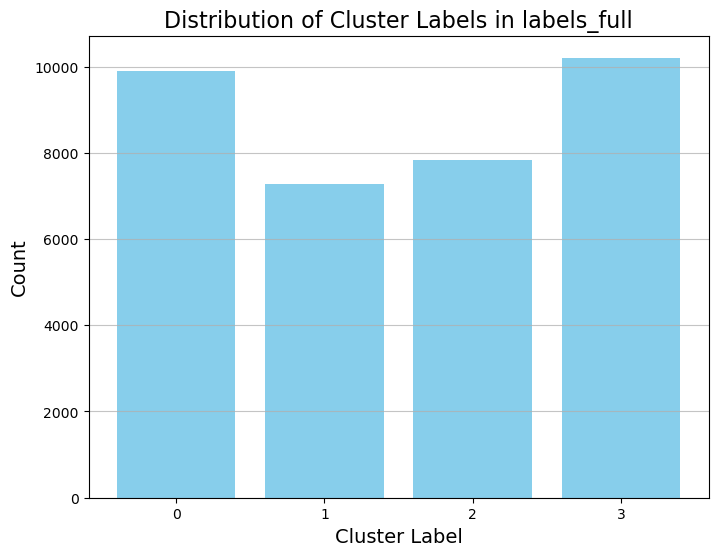

In [41]:

values, counts = np.unique(
    cluster_da_filtered.values[~np.isnan(cluster_da_filtered.values)],
    return_counts=True
)

print(dict(zip(values, counts)))

# Plot a histogram of the values in labels_full
plt.figure(figsize=(8, 6))
plt.bar(values, counts, color='skyblue')
plt.xlabel('Cluster Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Cluster Labels in labels_full', fontsize=16)
plt.xticks(values)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [56]:
cluster_da_filtered


<xarray.DataArray (ESM_run: 193, time: 1523)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan,  3., nan],
       [nan, nan, nan, ...,  3., nan, nan]])
Coordinates:
  * time     (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
  * ESM_run  (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...

In [ ]:
# Convert to dataframe with time, ESM_run, and cluster_id columns
df = cluster_da_filtered.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# df = df.drop(columns=['crs', 'gridtype'])
# Remove rows where cluster is NaN
df = df.dropna(subset=['cluster'])
# Make cluster an integer
df['cluster'] = df['cluster'].astype(int)
df
df['ESM'] = df['ESM_run'].str.split('_').str[0]
df['run'] = df['ESM_run'].str.split('_').str[1]
# Change df['time'] to datetime
df['time'] = pd.to_datetime(df['time'].values.astype('datetime64[ns]'))
df['dayofyear'] = df['time'].dt.dayofyear
df

# ────────────── 4) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"] = df["time"].apply(lambda x: x.month)
df['year'] = df["time"].apply(lambda x: x.year)
df["season"] = df["month"].map(month_to_season)

# ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

# ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
yearly_counts = (
    df
    .groupby(["cluster", df["year"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
yearly_frac = yearly_counts.div(yearly_counts.sum(axis=0), axis=1)

# ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
doy_counts = (
    df
    .groupby(["cluster", df["dayofyear"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
doy_frac = doy_counts.div(doy_counts.sum(axis=0), axis=1)

# ────────────── 7) Count samples of each cluster overall ──────────────
cluster_counts = df['cluster'].value_counts()


In [75]:
cluster_counts

cluster
3    10204
0     9887
2     7842
1     7284
Name: count, dtype: int64

In [127]:
# Convert to dataframe with time, ESM_run, and cluster_id columns
df_all = cluster_da.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# df_all = df_all.drop(columns=['crs', 'gridtype'])
# Remove rows where cluster is NaN
df_all = df_all.dropna(subset=['cluster'])
# Make cluster an integer
df_all['cluster'] = df_all['cluster'].astype(int)
df_all
df_all['ESM'] = df_all['ESM_run'].str.split('_').str[0]
df_all['run'] = df_all['ESM_run'].str.split('_').str[1]
# Change df_all['time'] to datetime
df_all['time'] = pd.to_datetime(df_all['time'].values.astype('datetime64[ns]'))
df_all['dayofyear'] = df_all['time'].dt.dayofyear
df_all

# ────────────── 4) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df_all["month"] = df_all["time"].apply(lambda x: x.month)
df_all['year'] = df_all["time"].apply(lambda x: x.year)
df_all["season"] = df_all["month"].map(month_to_season)

# ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
monthly_counts_all = (
    df_all
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)

# If you want fractions instead of raw counts, you can do:
monthly_frac_all = monthly_counts_all.div(monthly_counts_all.sum(axis=0), axis=1)

# ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
yearly_counts_all = (
    df_all
    .groupby(["cluster", df_all["year"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
yearly_frac_all = yearly_counts_all.div(yearly_counts_all.sum(axis=0), axis=1)

# ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
doy_counts_all = (
    df_all
    .groupby(["cluster", df_all["dayofyear"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
doy_frac_all = doy_counts_all.div(doy_counts_all.sum(axis=0), axis=1)

# ────────────── 7) Count samples of each cluster overall ──────────────
cluster_counts_all = df_all['cluster'].value_counts()


### Only cluster center maps

/tmp/ipykernel_1549425/77119595.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


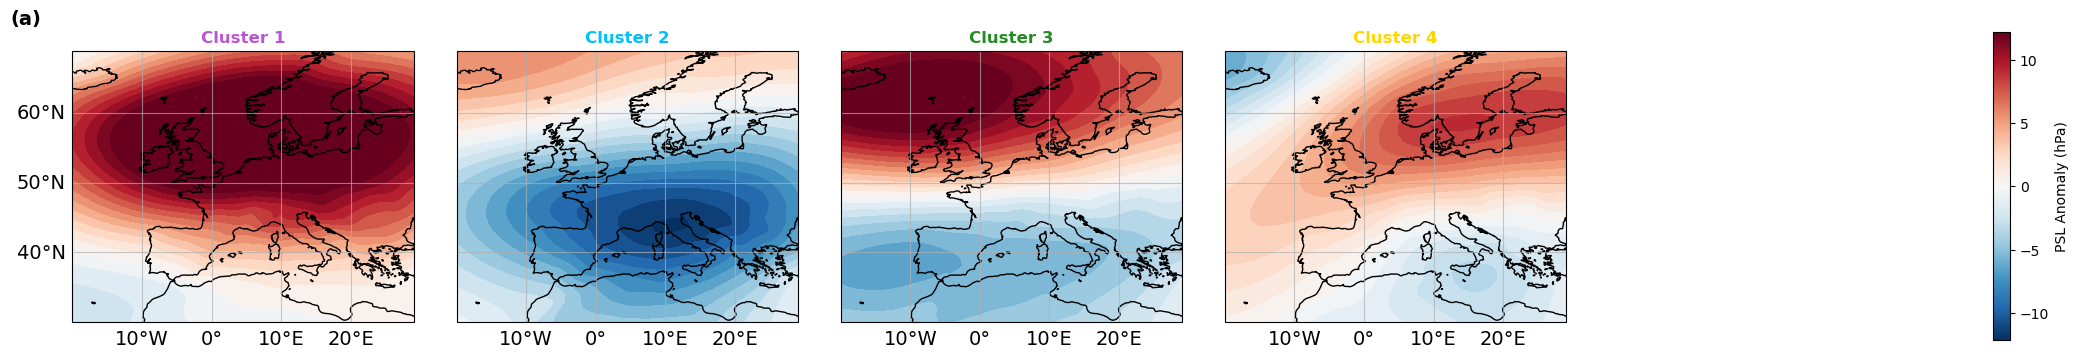

In [77]:
# Define cluster title colors (match figure)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin # np.nanmax(centroids_unweighted / 100.0)

# 2) Decide on subplot grid
ncols = 5
nrows = 1

# 3) Create figure + GridSpec (extra col for colorbar)
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

lons = ((ts_datasets_filtered['lon'].values + 180) % 360) - 180
lats = ts_datasets_filtered['lat'].values

for i in range(4):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # Plot with red-blue color scheme
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i, :, :] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)

    ax.set_title(f"Cluster {i + 1}", fontsize=12, color=cluster_colors[i], fontweight='bold')

# 4) Add (a) label
fig.text(0.1, 0.9, "(a)", fontsize=14, fontweight='bold')

# 5) Create ScalarMappable for colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

# 6) Add vertical colorbar on the right
cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout()
plt.show()

### Calculate dates from events

In [ ]:
LEE_dat_dl = create_date_list(LEE_dat, cluster_da)

In [86]:
# Sort df by ESM_run and time
df.sort_values(by=["ESM_run", "time"])


,ESM_run,time,cluster,ESM,run,dayofyear,month,year,season
3050,ACCESS-CM2_r1i1p1f1,2015-01-05,1,ACCESS-CM2,r1i1p1f1,5,1,2015,DJF
3052,ACCESS-CM2_r1i1p1f1,2015-01-07,2,ACCESS-CM2,r1i1p1f1,7,1,2015,DJF
3053,ACCESS-CM2_r1i1p1f1,2015-01-08,3,ACCESS-CM2,r1i1p1f1,8,1,2015,DJF
3063,ACCESS-CM2_r1i1p1f1,2015-01-18,1,ACCESS-CM2,r1i1p1f1,18,1,2015,DJF
3064,ACCESS-CM2_r1i1p1f1,2015-01-19,3,ACCESS-CM2,r1i1p1f1,19,1,2015,DJF
...,...,...,...,...,...,...,...,...,...
289358,UKESM1-0-LL_r8i1p1f2,2024-12-20,0,UKESM1-0-LL,r8i1p1f2,355,12,2024,DJF
289359,UKESM1-0-LL_r8i1p1f2,2024-12-21,0,UKESM1-0-LL,r8i1p1f2,356,12,2024,DJF
289363,UKESM1-0-LL_r8i1p1f2,2024-12-25,3,UKESM1-0-LL,r8i1p1f2,360,12,2024,DJF
289368,UKESM1-0-LL_r8i1p1f2,2024-12-30,2,UKESM1-0-LL,r8i1p1f2,365,12,2024,DJF


In [82]:
LEE_dat_dl

,Dates,ESM_run,Cluster
0,2015-01-05,ACCESS-CM2_r1i1p1f1,1.0
1,2015-01-07,ACCESS-CM2_r1i1p1f1,2.0
2,2015-01-08,ACCESS-CM2_r1i1p1f1,3.0
3,2015-01-18,ACCESS-CM2_r1i1p1f1,1.0
4,2015-01-19,ACCESS-CM2_r1i1p1f1,3.0
...,...,...,...
35212,2024-12-20,UKESM1-0-LL_r8i1p1f2,0.0
35213,2024-12-21,UKESM1-0-LL_r8i1p1f2,0.0
35214,2024-12-25,UKESM1-0-LL_r8i1p1f2,3.0
35215,2024-12-30,UKESM1-0-LL_r8i1p1f2,2.0


In [101]:
LEE_7_dl = create_date_list(LEE_7, cluster_da)

In [103]:
LEE_7_dl#['Cluster'].isna().sum()

,Dates,ESM_run,Cluster
0,2016-12-21,ACCESS-CM2_r1i1p1f1,1
1,2016-12-22,ACCESS-CM2_r1i1p1f1,2
2,2016-12-23,ACCESS-CM2_r1i1p1f1,2
3,2016-12-24,ACCESS-CM2_r1i1p1f1,2
4,2016-12-25,ACCESS-CM2_r1i1p1f1,2
...,...,...,...
16655,2024-12-21,UKESM1-0-LL_r8i1p1f2,0
16656,2024-12-22,UKESM1-0-LL_r8i1p1f2,0
16657,2024-12-23,UKESM1-0-LL_r8i1p1f2,0
16658,2024-12-24,UKESM1-0-LL_r8i1p1f2,3


In [112]:
LEE_14_dl = create_date_list(LEE_14, cluster_da)

In [114]:
LEE_14_dl


,Dates,ESM_run,Cluster
0,2016-12-20,ACCESS-CM2_r1i1p1f1,1
1,2016-12-21,ACCESS-CM2_r1i1p1f1,1
2,2016-12-22,ACCESS-CM2_r1i1p1f1,2
3,2016-12-23,ACCESS-CM2_r1i1p1f1,2
4,2016-12-24,ACCESS-CM2_r1i1p1f1,2
...,...,...,...
10131,2022-12-21,UKESM1-0-LL_r8i1p1f2,1
10132,2022-12-22,UKESM1-0-LL_r8i1p1f2,1
10133,2022-12-23,UKESM1-0-LL_r8i1p1f2,1
10134,2022-12-24,UKESM1-0-LL_r8i1p1f2,1


### Plot for event days distributions of cluster for different event lengths

In [115]:
# Compute relative frequencies for each DataFrame
dfs = {
    'Daily': pd.DataFrame(LEE_dat_dl),
    '7-day': pd.DataFrame(LEE_7_dl),
    '14-day': pd.DataFrame(LEE_14_dl)
}

# Get sorted list of all clusters present across datasets
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))

# Prepare proportions matrix
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}

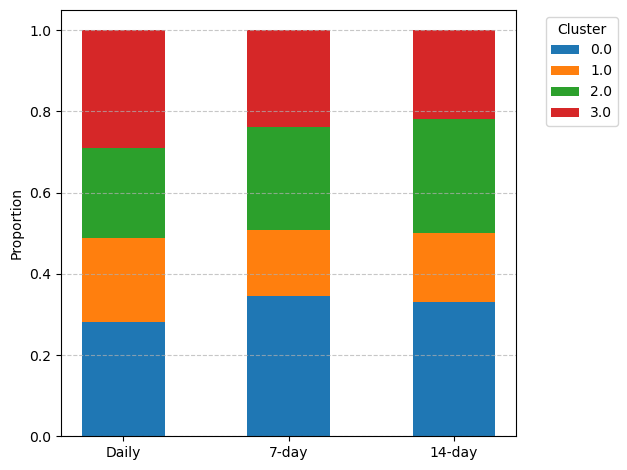

In [116]:
# Plotting
fig, ax = plt.subplots()
bar_width = 0.5
x = np.arange(len(dfs))  # positions for the three bars

# Stack bars
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax.bar(x, heights, bar_width, bottom=bottom, label=str(cluster))
    bottom += heights

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

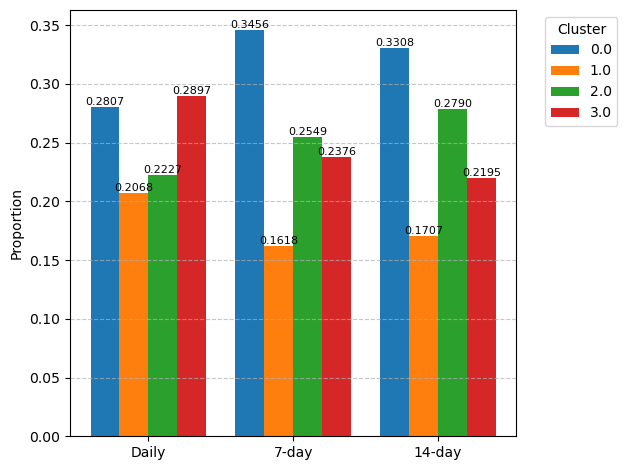

In [117]:
# Plotting
fig, ax = plt.subplots()
num_clusters = len(all_clusters)
bar_width = 0.8 / num_clusters  # make sure total width fits

x = np.arange(len(dfs))  # positions for the main groups

# Plot side-by-side bars
for i, cluster in enumerate(all_clusters):
    heights = [data[name].get(cluster, 0) for name in dfs]
    offset_x = x + i * bar_width - (bar_width * (num_clusters - 1) / 2)  # center the bars
    bars = ax.bar(offset_x, heights, bar_width, label=str(cluster))

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Plot clusters against ESM

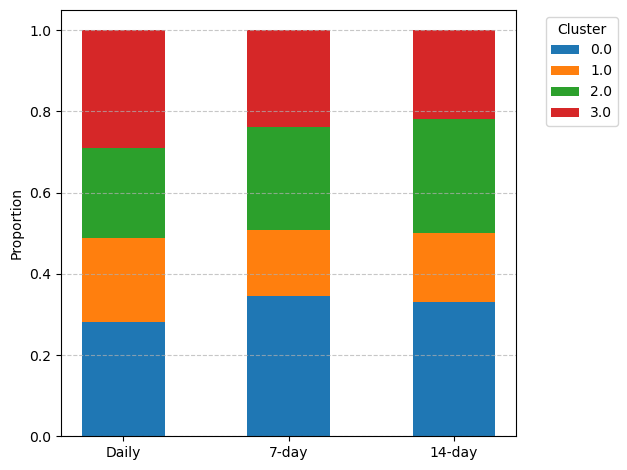

In [118]:
# Plotting
fig, ax = plt.subplots()
bar_width = 0.5
x = np.arange(len(dfs))  # positions for the three bars

# Stack bars
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax.bar(x, heights, bar_width, bottom=bottom, label=str(cluster))
    bottom += heights

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

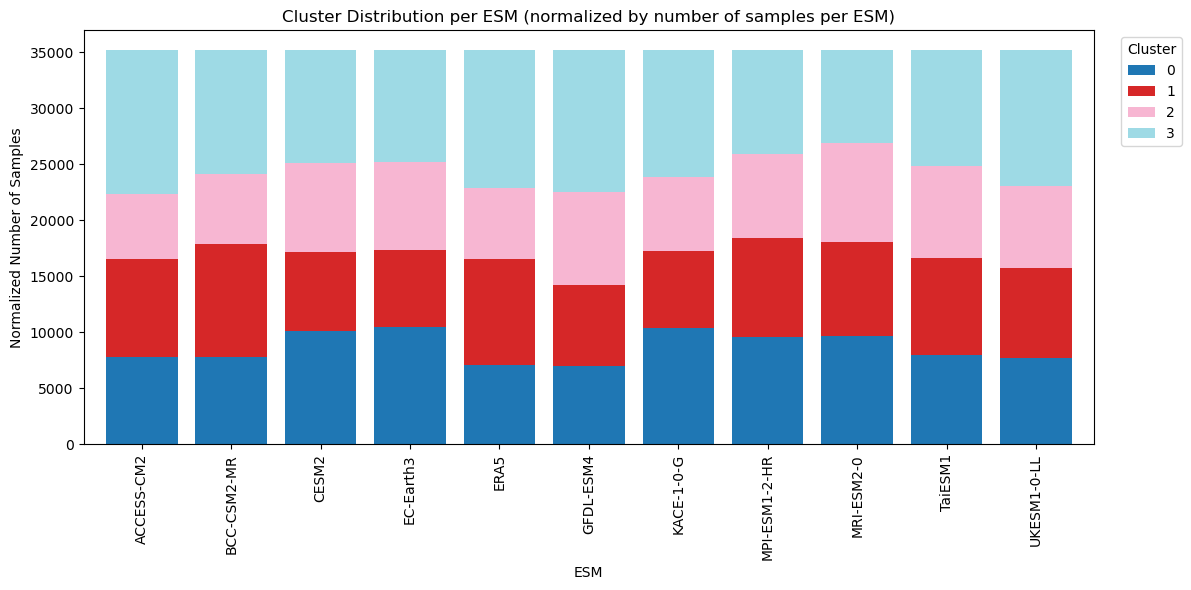

In [119]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

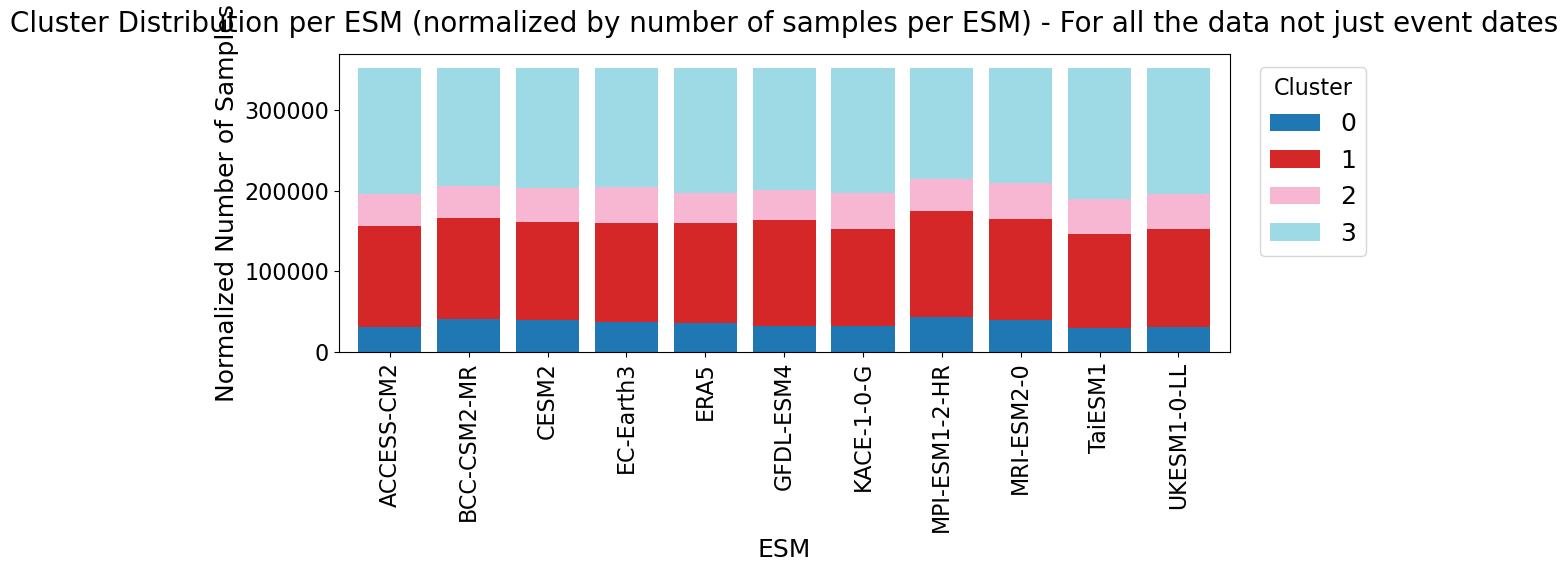

In [128]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df_all['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df_all.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM) - For all the data not just event dates")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Large Plot combined

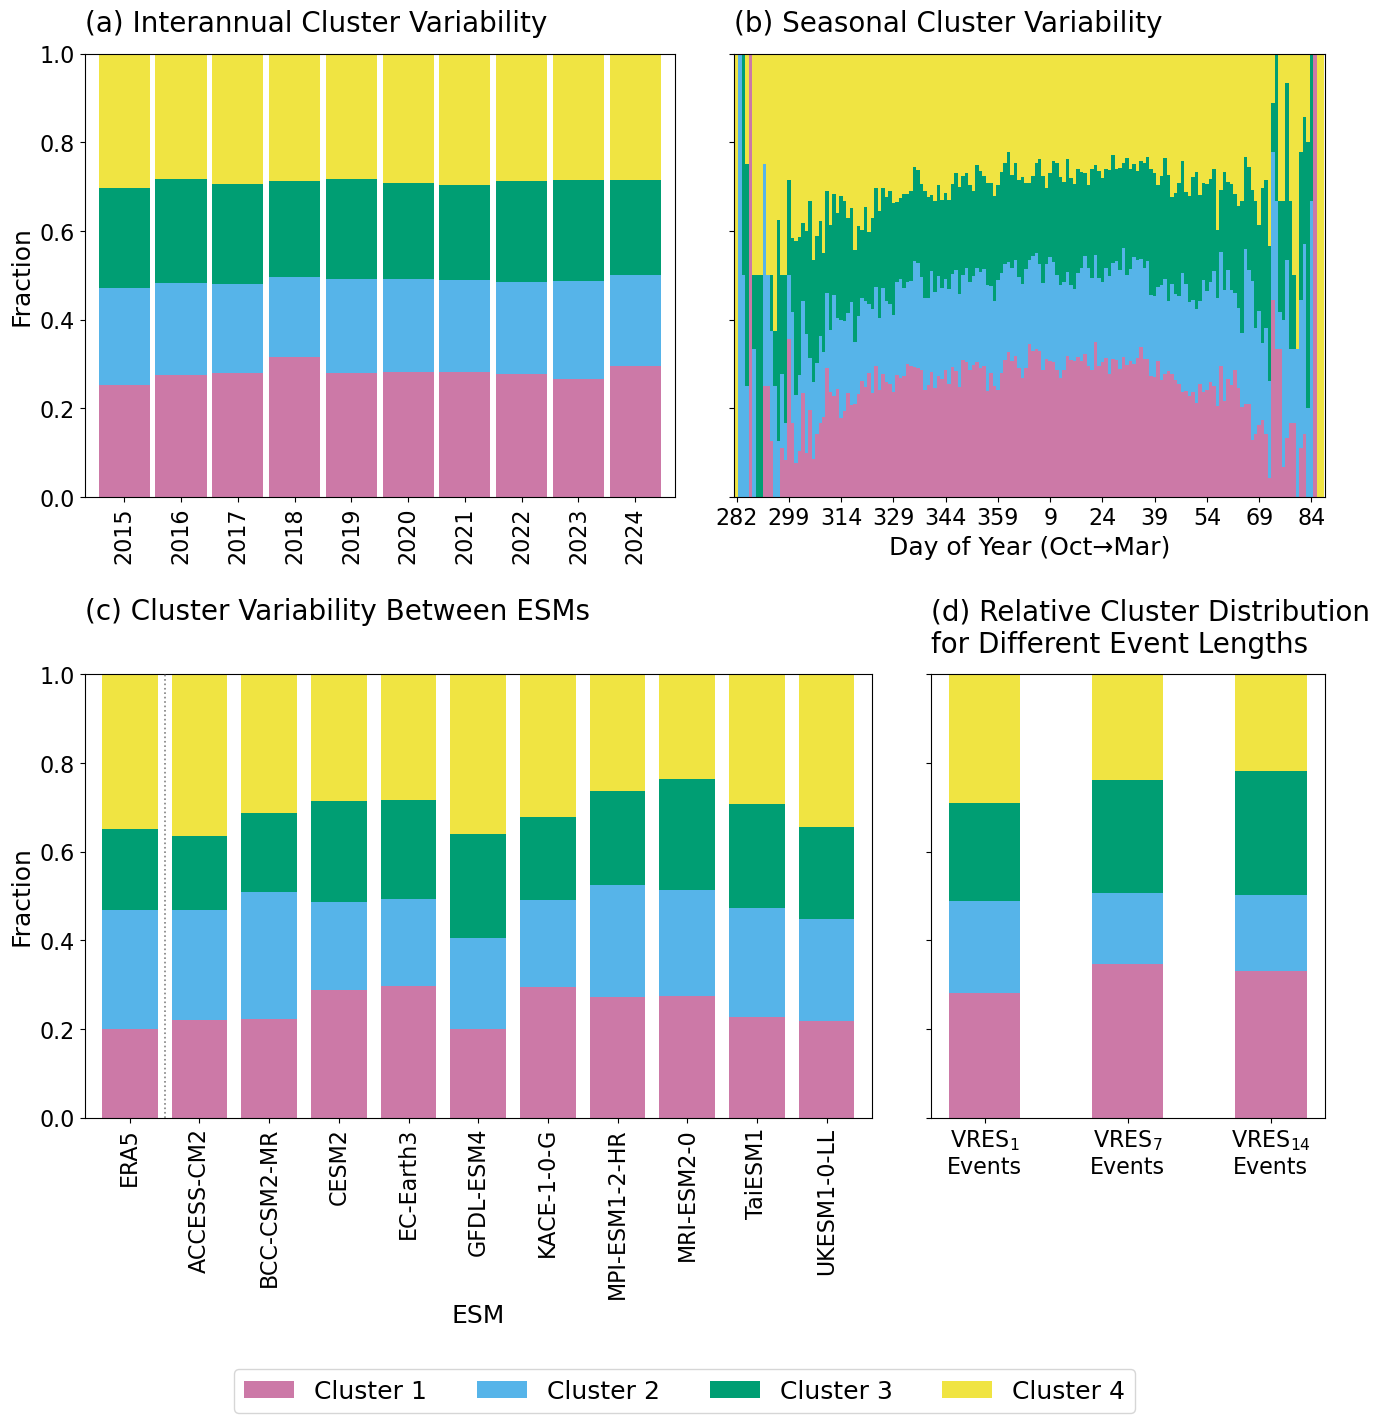

In [120]:
mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 20,
})
plt.rcParams['axes.titlepad'] = 16  # default padding for all titles (in points)

# --- palette (re-use your colors) ---
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
# colorblind-friendly hex colours (Okabe–Ito subset)
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# Create 2x2 figure
fig = plt.figure(figsize=(16, 14))
# gs = GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.1)
outer = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)  # hspace adjusts the vertical space between the two rows

top = outer[0].subgridspec(1, 2, wspace=0.1)
ax_a = fig.add_subplot(top[0, 0])  # (b) links
ax_b = fig.add_subplot(top[0, 1])  # (c) rechts

# --------------------------
# (a) Top-left: Yearly fractions (stacked bar)
# --------------------------
# ax_a = fig.add_subplot(gs[0, 0])
df_year = yearly_frac.T  # as in your original code

df_year.plot(
    kind="bar", stacked=True, ax=ax_a, width=0.9,
    color=[cluster_palette[int(c)] for c in df_year.columns],
    legend=False
)
ax_a.set_xlabel("")
ax_a.set_ylabel("Fraction")
ax_a.set_ylim(0, 1)
ax_a.set_xticklabels(df_year.index, rotation=90) # , ha="right"
# ax_a.set_title("(a) Yearly fractions", fontsize=20, fontweight='bold', loc='left')
ax_a.set_title("(a) Interannual Cluster Variability", fontsize=20, loc='left')

# --------------------------
# (b) Bottom-left: simple cluster counts bar (replaces the maps)
# --------------------------
# ax_b = fig.add_subplot(gs[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=ax_b, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
ax_b.set_xlabel("Day of Year (Oct→Mar)")
ax_b.set_ylabel("")
# ax_b.set_ylabel("Fraction")
ax_b.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
ax_b.set_xticks(ticks)
ax_b.set_xticklabels(df_doy.index[ticks], rotation=0) #, ha="right"
ax_b.set_yticklabels([])
# fig.text(0.39, 0.57, "(b)", fontsize=20, fontweight="bold")
ax_b.set_title("(b) Seasonal Cluster Variability", fontsize=20, loc='left')


bottom = outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.1)
ax_c = fig.add_subplot(bottom[0, 0])  # (c) nimmt 2/3 Breite
ax_d = fig.add_subplot(bottom[0, 1])  # (d) nimmt 1/3 Breite
# --------------------------
# (c) Top-right: ESM stacked bar normalized per-ESM
# --------------------------
# ax_c = fig.add_subplot(gs[1, 0])

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax_c,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
ax_c.set_xlabel("ESM")
ax_c.set_ylabel("Fraction")
ax_c.set_ylim(0, 1)
ax_c.set_title("(c) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
ax_c.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)


# --------------------------
# (d) Bottom-right: relative cluster distribution for 1/7/14-day events (your original logic)
# --------------------------
# ax_d = fig.add_subplot(gs[1, 1])
dfs = {
    r'$\mathrm{VRES}_{1}$' + '\n' + 'Events': pd.DataFrame(LEE_dat_dl),
    r'$\mathrm{VRES}_{7}$' + '\n' + 'Events': pd.DataFrame(LEE_7_dl),
    r'$\mathrm{VRES}_{14}$' + '\n' + 'Events': pd.DataFrame(LEE_14_dl)
}

all_clusters = sorted(set().union(*(df_['Cluster'].unique() for df_ in dfs.values())))
data = {
    name: df_['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df_ in dfs.items()
}

bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax_d.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {int(cluster)+1}", color=cluster_palette[int(cluster)])
    bottom += heights

ax_d.set_xticks(x)
ax_d.set_xticklabels(list(dfs.keys()), rotation=0)
ax_d.set_yticklabels([])
ax_d.set_ylabel('')
ax_d.set_ylim(0, 1)
# ax_d.set_title("(d) Relative cluster distribution (1/7/14-day)", fontsize=20, loc='left')
ax_d.set_title("(d) Relative Cluster Distribution \nfor Different Event Lengths", fontsize=20, loc='left')

# --------------------------
# Global legend (lower center) using consistent cluster handles
# --------------------------
legend_handles = [
    Patch(facecolor=cluster_palette[int(c)], label=f"Cluster {int(c)+1}")
    for c in all_clusters
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True
)

# final layout tweak and show
fig.subplots_adjust(bottom=0.12)
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_2x2.png', dpi=300, bbox_inches='tight')

plt.show()


In [80]:
cluster_counts

cluster
3    83543
1    78860
0    63733
2    62583
4    62541
Name: count, dtype: int64

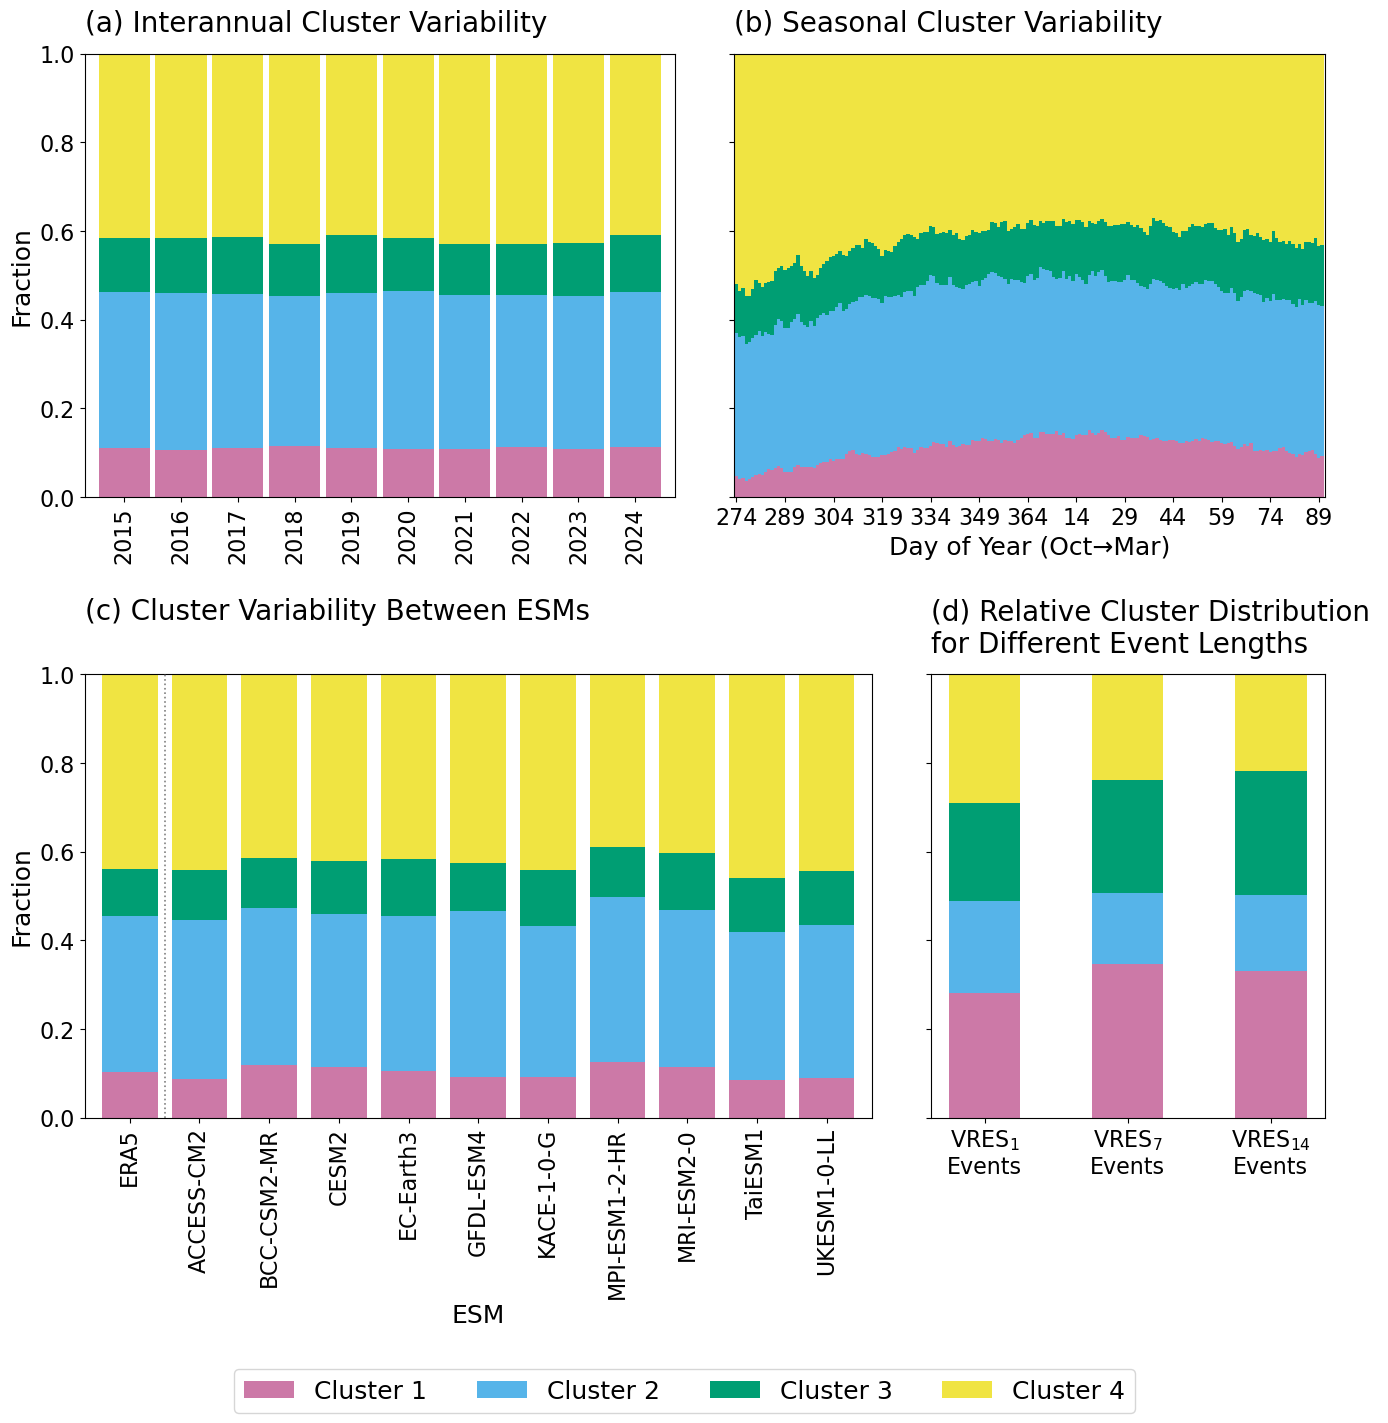

In [129]:
mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 20,
})
plt.rcParams['axes.titlepad'] = 16  # default padding for all titles (in points)

# --- palette (re-use your colors) ---
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
# colorblind-friendly hex colours (Okabe–Ito subset)
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# Create 2x2 figure
fig = plt.figure(figsize=(16, 14))
# gs = GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.1)
outer = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)  # hspace adjusts the vertical space between the two rows

top = outer[0].subgridspec(1, 2, wspace=0.1)
ax_a = fig.add_subplot(top[0, 0])  # (b) links
ax_b = fig.add_subplot(top[0, 1])  # (c) rechts

# --------------------------
# (a) Top-left: Yearly fractions (stacked bar)
# --------------------------
# ax_a = fig.add_subplot(gs[0, 0])
df_year = yearly_frac_all.T  # as in your original code

df_year.plot(
    kind="bar", stacked=True, ax=ax_a, width=0.9,
    color=[cluster_palette[int(c)] for c in df_year.columns],
    legend=False
)
ax_a.set_xlabel("")
ax_a.set_ylabel("Fraction")
ax_a.set_ylim(0, 1)
ax_a.set_xticklabels(df_year.index, rotation=90) # , ha="right"
# ax_a.set_title("(a) Yearly fractions", fontsize=20, fontweight='bold', loc='left')
ax_a.set_title("(a) Interannual Cluster Variability", fontsize=20, loc='left')

# --------------------------
# (b) Bottom-left: simple cluster counts bar (replaces the maps)
# --------------------------
# ax_b = fig.add_subplot(gs[0, 1])
days = doy_frac_all.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac_all[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=ax_b, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
ax_b.set_xlabel("Day of Year (Oct→Mar)")
ax_b.set_ylabel("")
# ax_b.set_ylabel("Fraction")
ax_b.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
ax_b.set_xticks(ticks)
ax_b.set_xticklabels(df_doy.index[ticks], rotation=0) #, ha="right"
ax_b.set_yticklabels([])
# fig.text(0.39, 0.57, "(b)", fontsize=20, fontweight="bold")
ax_b.set_title("(b) Seasonal Cluster Variability", fontsize=20, loc='left')


bottom = outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.1)
ax_c = fig.add_subplot(bottom[0, 0])  # (c) nimmt 2/3 Breite
ax_d = fig.add_subplot(bottom[0, 1])  # (d) nimmt 1/3 Breite
# --------------------------
# (c) Top-right: ESM stacked bar normalized per-ESM
# --------------------------
# ax_c = fig.add_subplot(gs[1, 0])

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df_all.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax_c,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
ax_c.set_xlabel("ESM")
ax_c.set_ylabel("Fraction")
ax_c.set_ylim(0, 1)
ax_c.set_title("(c) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
ax_c.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)


# --------------------------
# (d) Bottom-right: relative cluster distribution for 1/7/14-day events (your original logic)
# --------------------------
# ax_d = fig.add_subplot(gs[1, 1])
dfs = {
    r'$\mathrm{VRES}_{1}$' + '\n' + 'Events': pd.DataFrame(LEE_dat_dl),
    r'$\mathrm{VRES}_{7}$' + '\n' + 'Events': pd.DataFrame(LEE_7_dl),
    r'$\mathrm{VRES}_{14}$' + '\n' + 'Events': pd.DataFrame(LEE_14_dl)
}

all_clusters = sorted(set().union(*(df_['Cluster'].unique() for df_ in dfs.values())))
data = {
    name: df_['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df_ in dfs.items()
}

bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax_d.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {int(cluster)+1}", color=cluster_palette[int(cluster)])
    bottom += heights

ax_d.set_xticks(x)
ax_d.set_xticklabels(list(dfs.keys()), rotation=0)
ax_d.set_yticklabels([])
ax_d.set_ylabel('')
ax_d.set_ylim(0, 1)
# ax_d.set_title("(d) Relative cluster distribution (1/7/14-day)", fontsize=20, loc='left')
ax_d.set_title("(d) Relative Cluster Distribution \nfor Different Event Lengths", fontsize=20, loc='left')

# --------------------------
# Global legend (lower center) using consistent cluster handles
# --------------------------
legend_handles = [
    Patch(facecolor=cluster_palette[int(c)], label=f"Cluster {int(c)+1}")
    for c in all_clusters
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True
)

# final layout tweak and show
fig.subplots_adjust(bottom=0.12)
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_2x2.png', dpi=300, bbox_inches='tight')

plt.show()


In [139]:
cluster_counts[0:4]

cluster
3    10204
0     9887
2     7842
1     7284
Name: count, dtype: int64

In [146]:

cluster_counts_sorted = cluster_counts.sort_index()
print(cluster_counts_sorted)

cluster_counts_all_sorted = cluster_counts_all.sort_index()
print(cluster_counts_all_sorted)

cluster_counts_ratio = cluster_counts_sorted / cluster_counts_all_sorted
cluster_counts_ratio


cluster
0     9887
1     7284
2     7842
3    10204
Name: count, dtype: int64
cluster
0     38568
1    122338
2     42933
3    147421
Name: count, dtype: int64


cluster
0    0.256352
1    0.059540
2    0.182657
3    0.069217
Name: count, dtype: float64

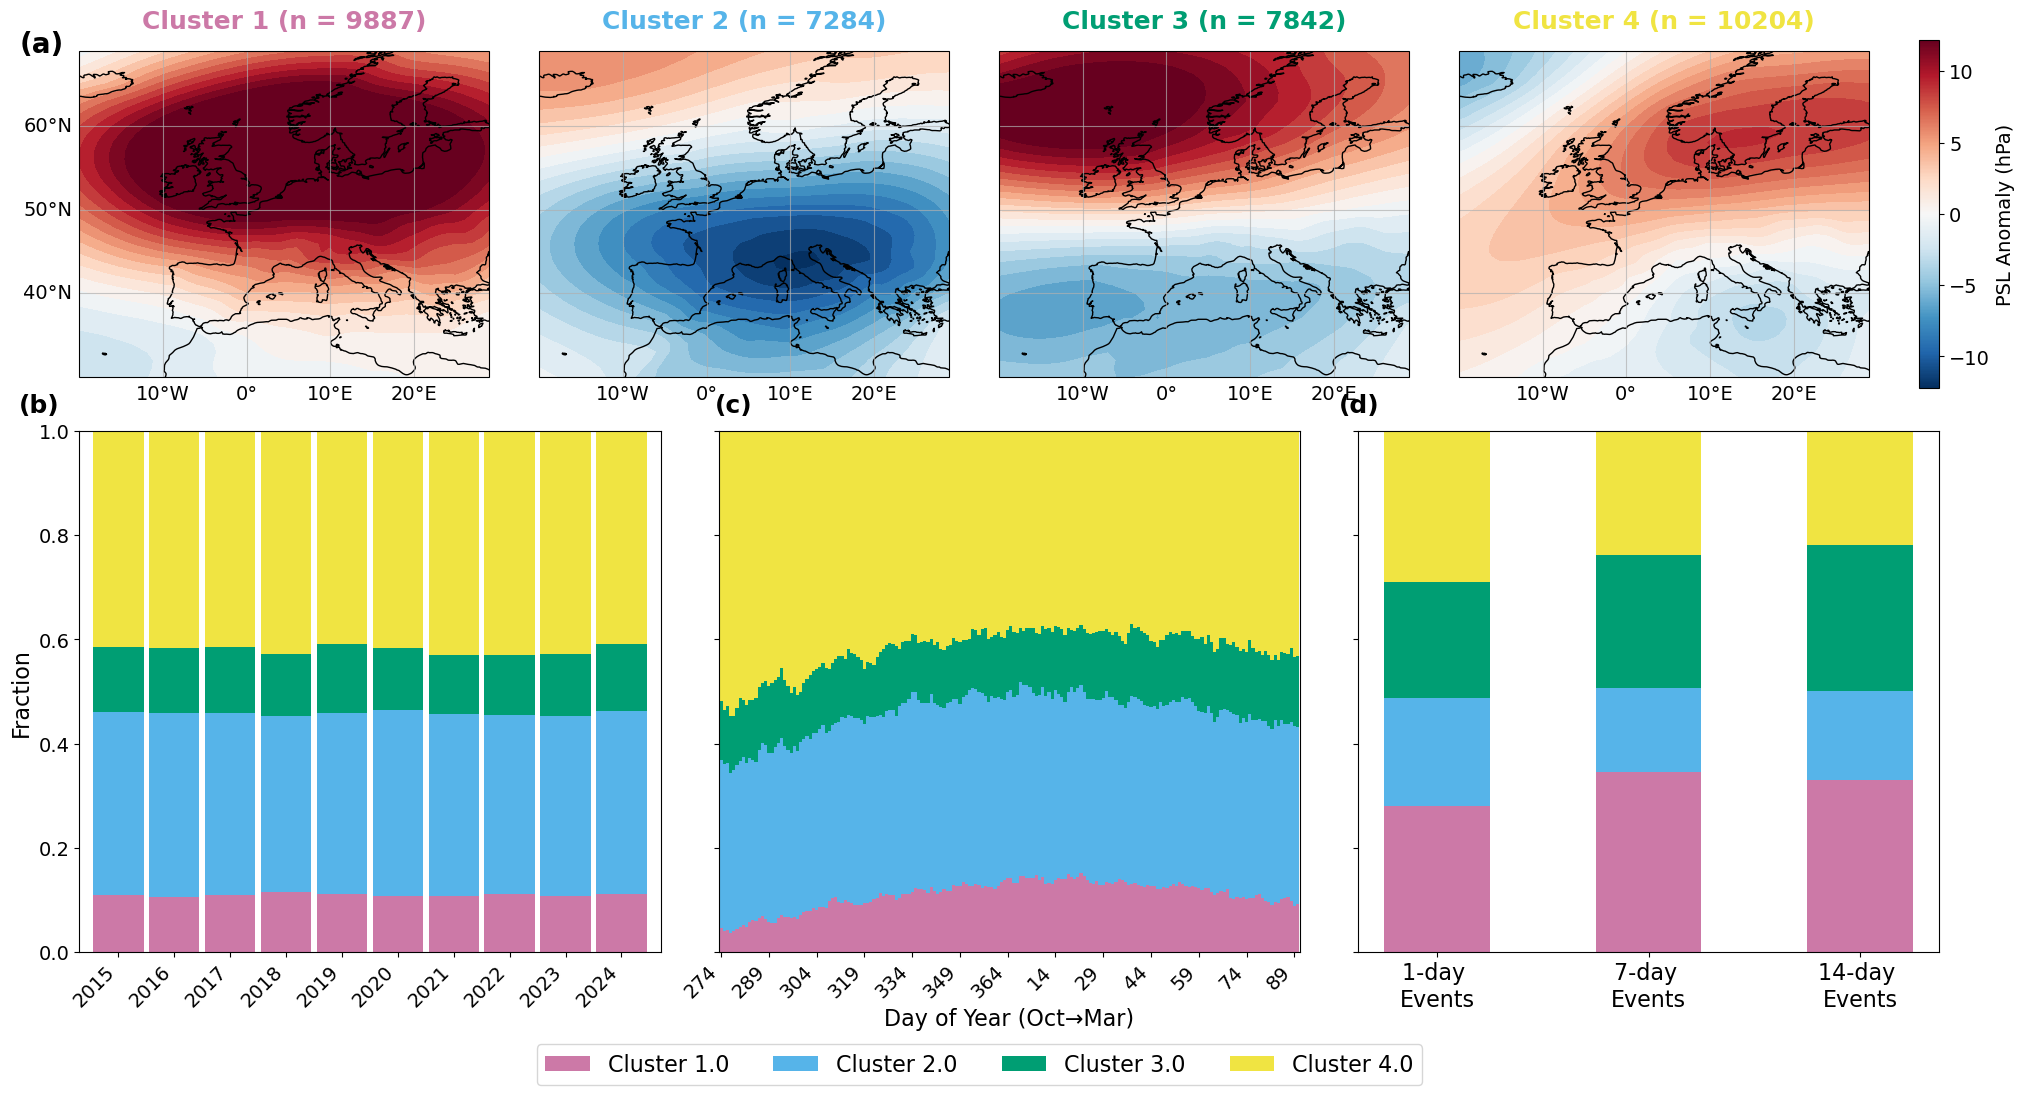

In [147]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 18,      # axes titles
    'axes.labelsize': 16,      # x/y labels
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 16,     # legend text
    'figure.titlesize': 18,    # figure title (if used)
})

# Create a color palette for clusters
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×5 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 5 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(4):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i],
                 fontsize=18, fontweight='bold')   # increased title fontsize
    ax.tick_params(labelsize=14)

# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 4])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=14)  # increased
cbar.ax.tick_params(labelsize=14)

fig.text(0.1, 0.87, "(a)", fontsize=20, fontweight='bold')  # increased

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
df_year = yearly_frac_all.T

df_year.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_xlabel("", fontsize=16)
axb.set_ylabel("Fraction", fontsize=16)
axb.set_ylim(0, 1)
axb.set_xticklabels(df_year.index, rotation=45, ha="right", fontsize=12)
axb.tick_params(labelsize=14)
fig.text(0.1, 0.57, "(b)", fontsize=18, fontweight="bold")

# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac_all.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac_all[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)", fontsize=16)
axc.set_ylabel("", fontsize=16)
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right", fontsize=12)
axc.tick_params(labelsize=14)
# remove ytick labels as before
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=18, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day
axd = fig.add_subplot(row2[0, 2])
# Assuming LEE_dat_dl, LEE_7_dl, LEE_14_dl DataFrames exist with 'Cluster'
dfs = {
    '1-day \nEvents': pd.DataFrame(LEE_dat_dl),
    '7-day \nEvents': pd.DataFrame(LEE_7_dl),
    '14-day \nEvents': pd.DataFrame(LEE_14_dl)
}
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}
bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {cluster+1}", color=cluster_palette[cluster])
    bottom += heights
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys(), fontsize=16)
axd.set_yticklabels([])
axd.set_ylabel('', fontsize=16)
axd.set_ylim(0, 1)
# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, 0),
    title='',
    fontsize=16
)

fig.text(0.65, 0.57, "(d)", fontsize=18, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined.png', dpi=300, bbox_inches='tight')


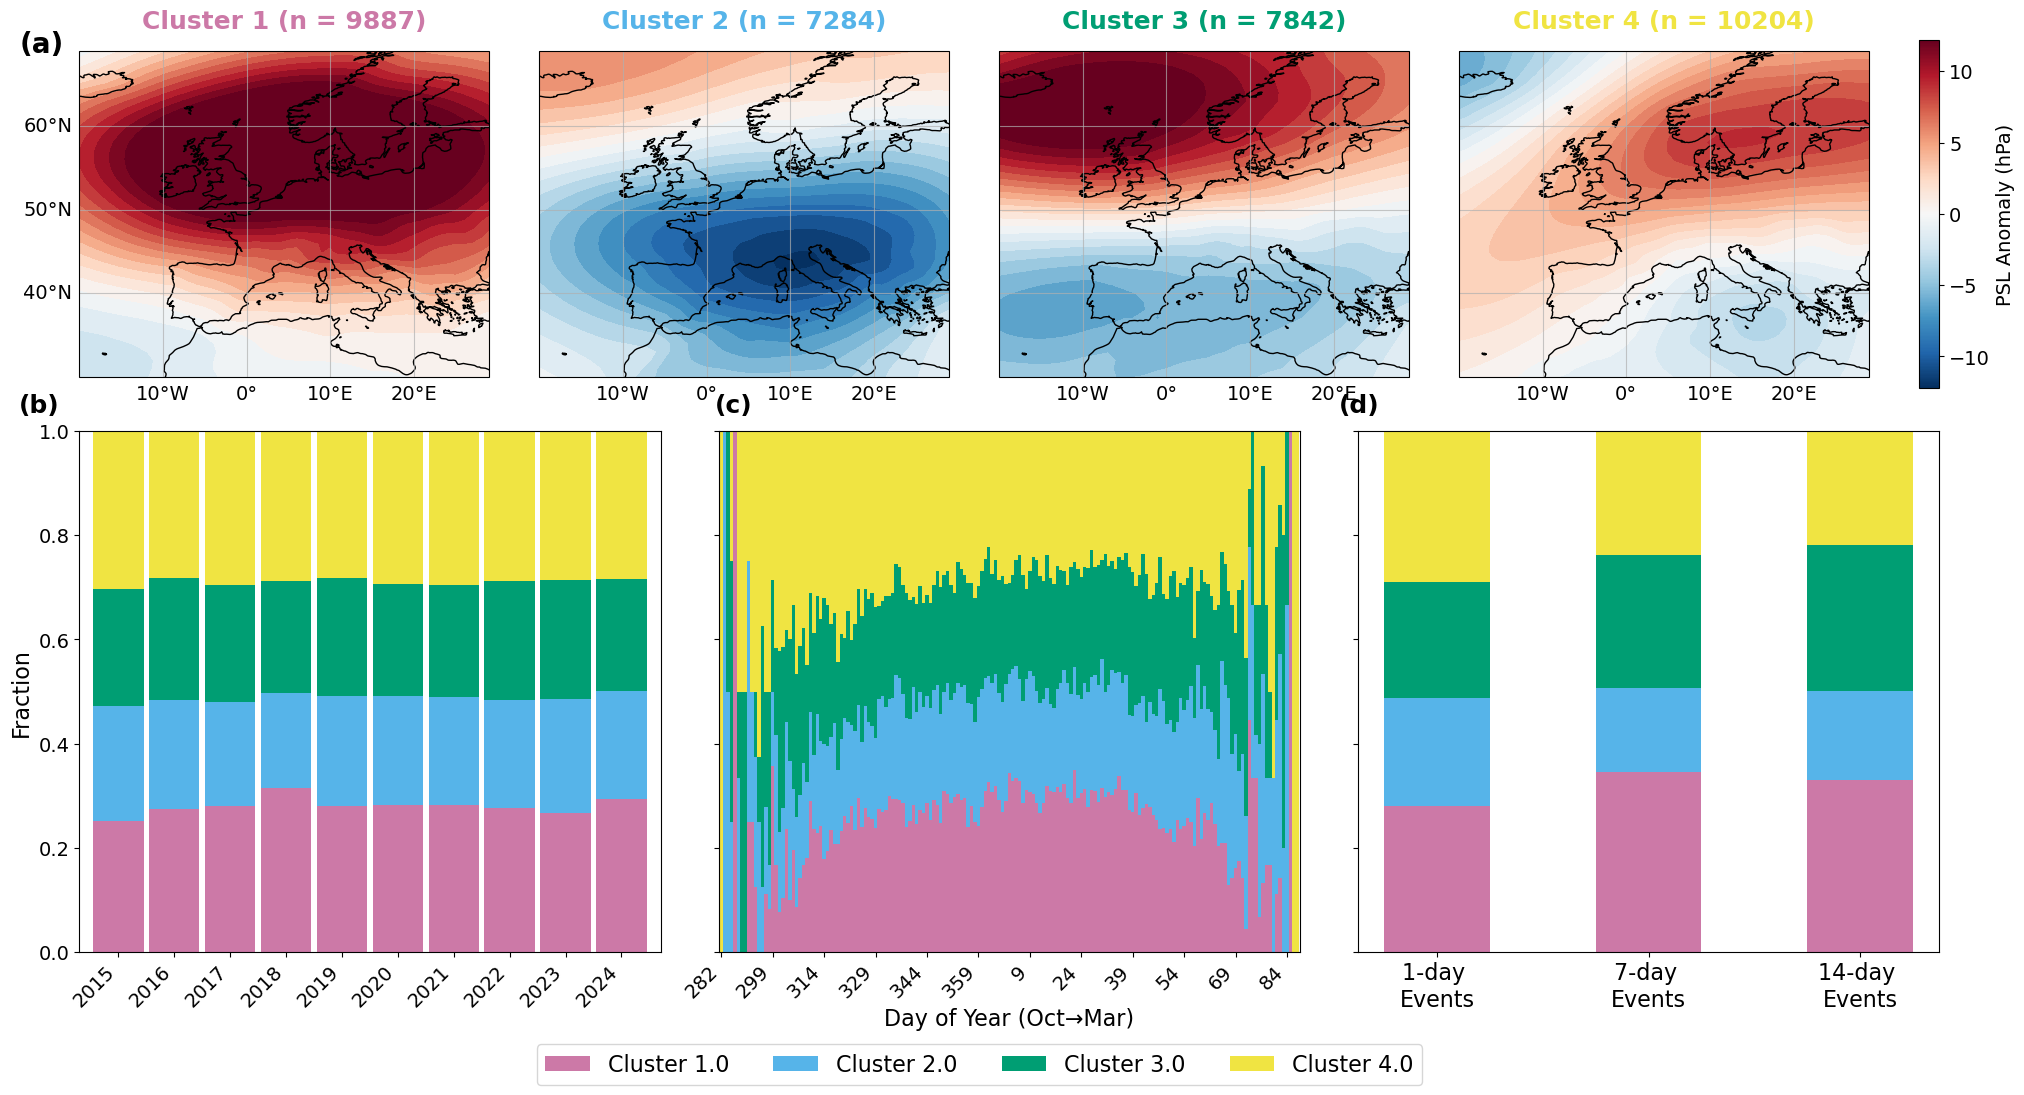

In [125]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 18,      # axes titles
    'axes.labelsize': 16,      # x/y labels
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 16,     # legend text
    'figure.titlesize': 18,    # figure title (if used)
})

# Create a color palette for clusters
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×5 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 5 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(4):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i],
                 fontsize=18, fontweight='bold')   # increased title fontsize
    ax.tick_params(labelsize=14)

# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 4])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=14)  # increased
cbar.ax.tick_params(labelsize=14)

fig.text(0.1, 0.87, "(a)", fontsize=20, fontweight='bold')  # increased

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
df_year = yearly_frac.T

df_year.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_xlabel("", fontsize=16)
axb.set_ylabel("Fraction", fontsize=16)
axb.set_ylim(0, 1)
axb.set_xticklabels(df_year.index, rotation=45, ha="right", fontsize=12)
axb.tick_params(labelsize=14)
fig.text(0.1, 0.57, "(b)", fontsize=18, fontweight="bold")

# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)", fontsize=16)
axc.set_ylabel("", fontsize=16)
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right", fontsize=12)
axc.tick_params(labelsize=14)
# remove ytick labels as before
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=18, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day
axd = fig.add_subplot(row2[0, 2])
# Assuming LEE_dat_dl, LEE_7_dl, LEE_14_dl DataFrames exist with 'Cluster'
dfs = {
    '1-day \nEvents': pd.DataFrame(LEE_dat_dl),
    '7-day \nEvents': pd.DataFrame(LEE_7_dl),
    '14-day \nEvents': pd.DataFrame(LEE_14_dl)
}
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}
bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {cluster+1}", color=cluster_palette[cluster])
    bottom += heights
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys(), fontsize=16)
axd.set_yticklabels([])
axd.set_ylabel('', fontsize=16)
axd.set_ylim(0, 1)
# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, 0),
    title='',
    fontsize=16
)

fig.text(0.65, 0.57, "(d)", fontsize=18, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined.png', dpi=300, bbox_inches='tight')


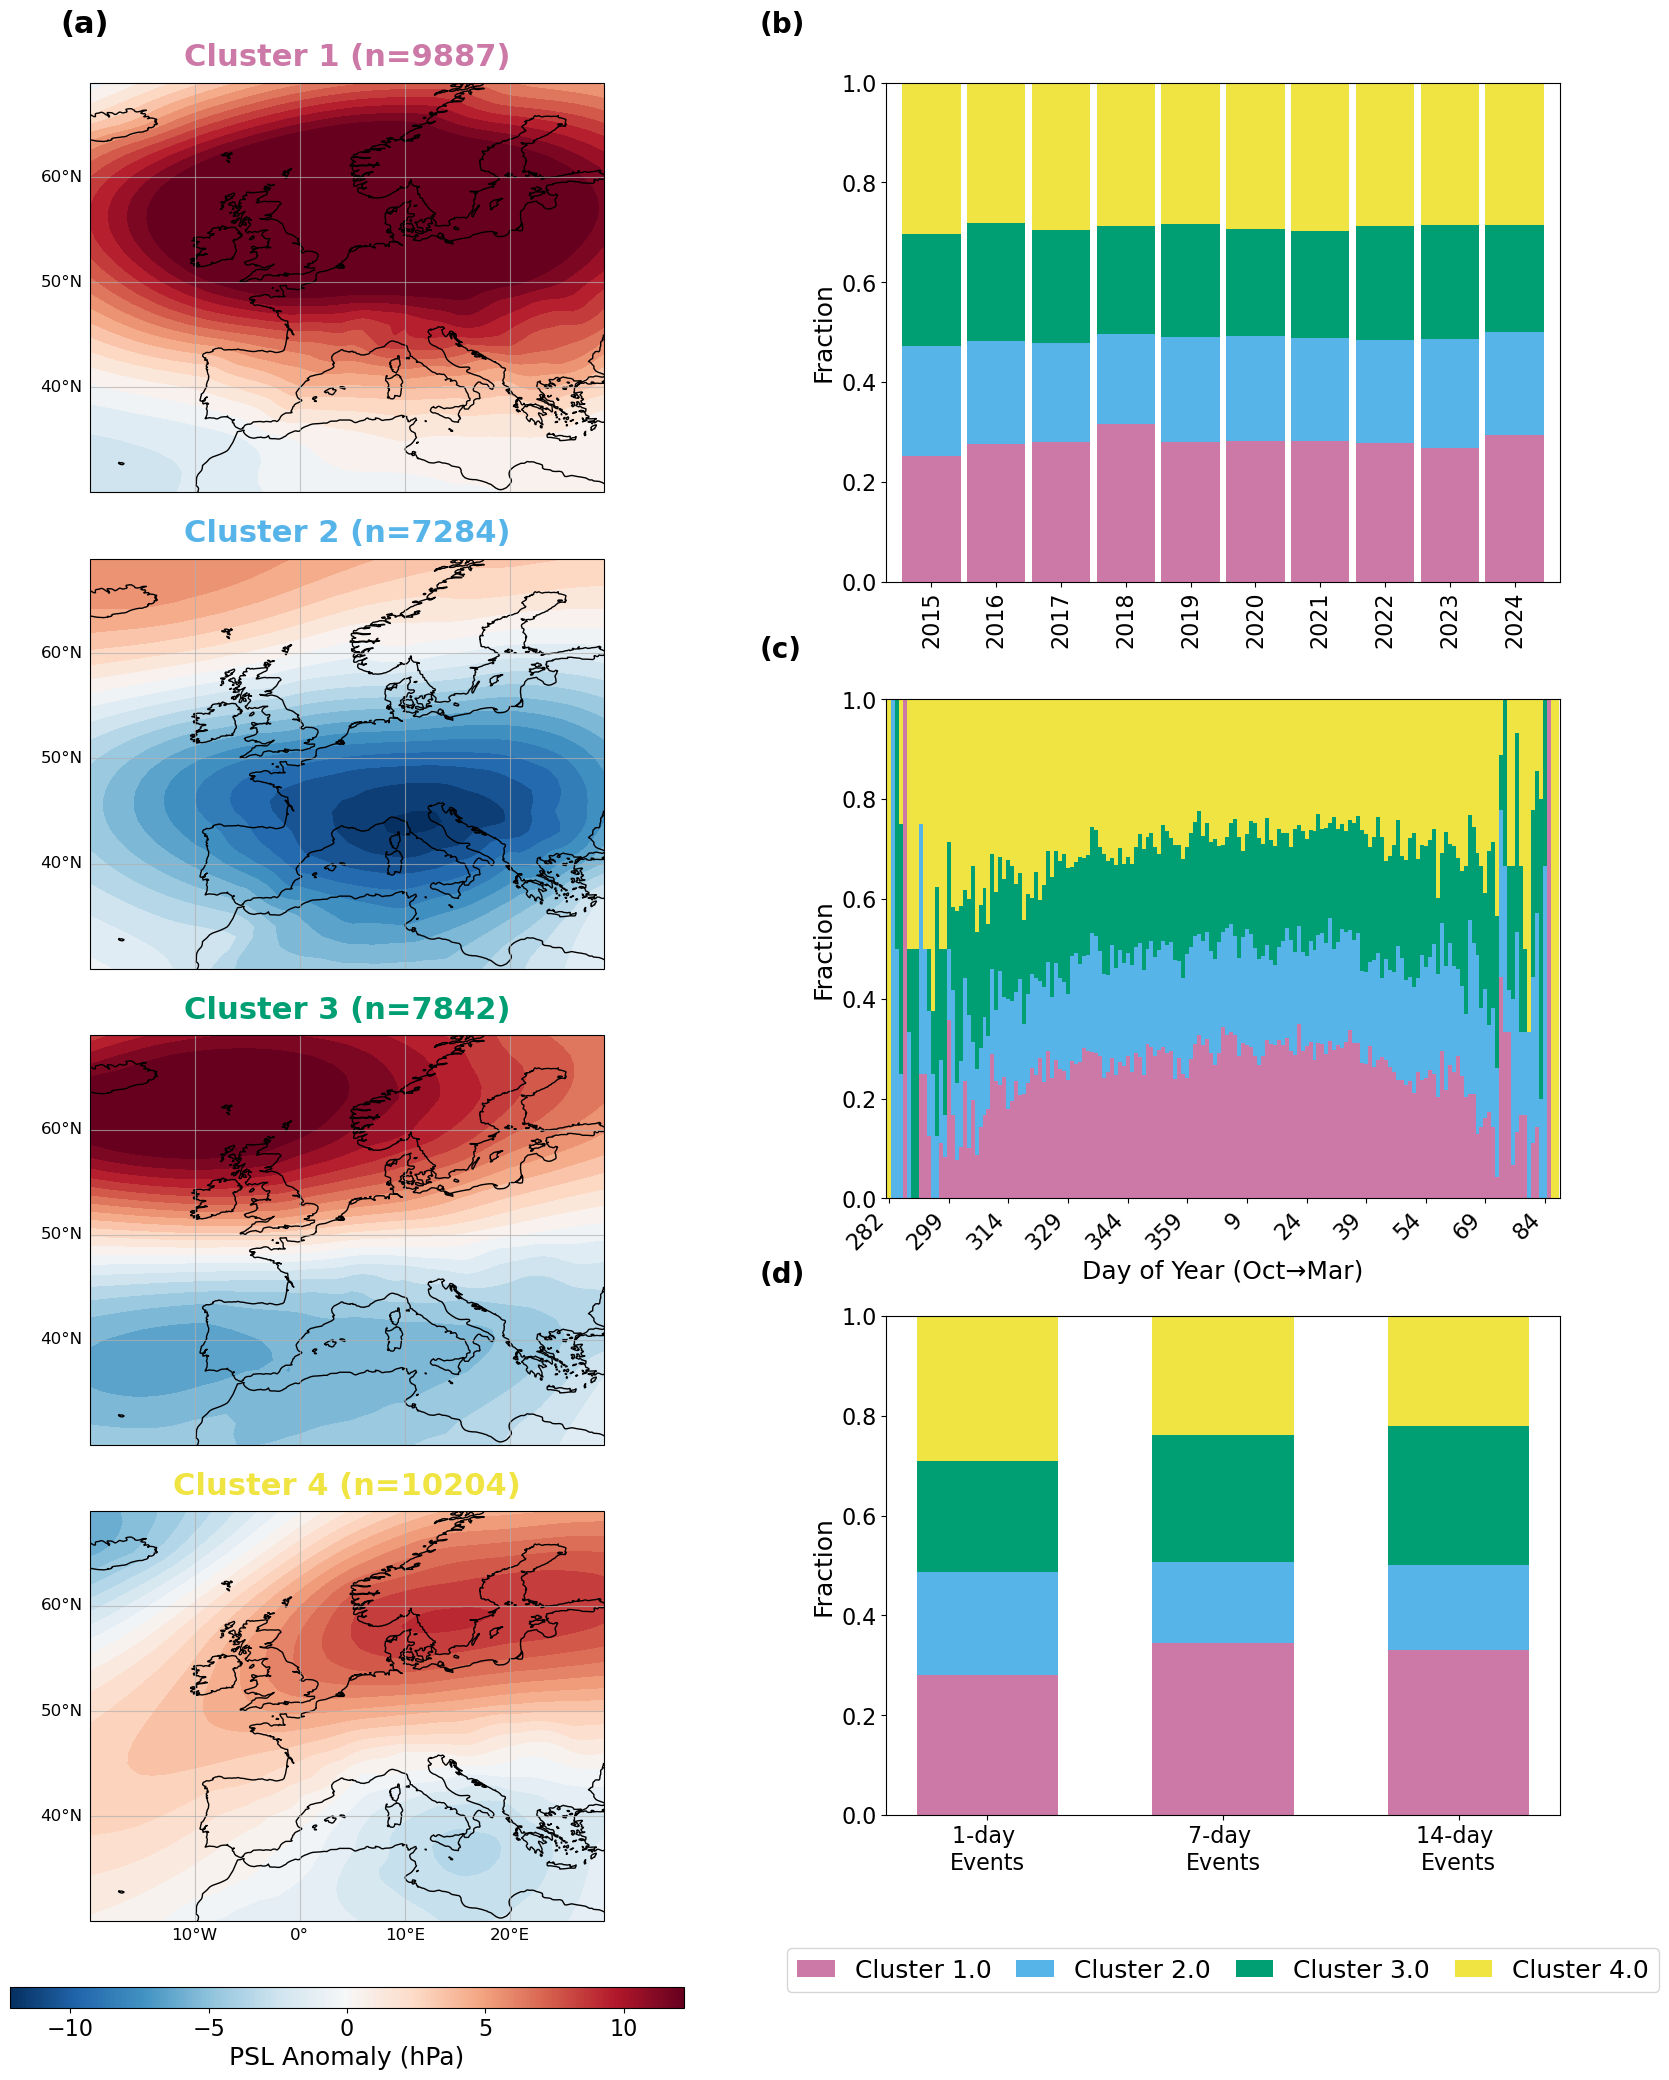

In [126]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 20,      # axes titles
    'axes.labelsize': 18,      # x/y labels
    'xtick.labelsize': 16,     # x tick labels
    'ytick.labelsize': 16,     # y tick labels
    'legend.fontsize': 18,     # legend text
    'figure.titlesize': 22,    # figure title (if used)
})

# make the entire figure a bit smaller than before
fig = plt.figure(figsize=(20, 25))
outer = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# ─── Left column: 4 maps + shared colorbar ──────────────────────────────
left_gs = outer[0].subgridspec(5, 1, height_ratios=[1,1,1,1,0.05], hspace=0.2)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin

for i in range(4):
    ax = fig.add_subplot(left_gs[i, 0], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, centroids_unweighted[i] / 100.0,
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7, ll=True, bl=(i==3), label_size=12)  # increased tick label size for maps
    ax.set_title(
        f"Cluster {i+1} (n={cluster_counts[i]})",
        color=cluster_colors[i],
        fontsize=22,              # increased
        fontweight='bold',
        pad=12
    )
    ax.tick_params(labelsize=16)  # increase tick labels

# colorbar in the tiny bottom row
cax = fig.add_subplot(left_gs[4, 0])
sm = ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cf.cmap)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('PSL Anomaly (hPa)', fontsize=18)  # increased
cbar.ax.tick_params(labelsize=16)

fig.text(0.15, 0.9, "(a)", fontsize=22, fontweight="bold")  # increased

# ─── Right column: 3 vertical panels (b),(c),(d) ─────────────────────────
right_gs = outer[1].subgridspec(4, 1, height_ratios=[1,1,1,0.15], hspace=0.3)

# (b) Yearly fractions
axb = fig.add_subplot(right_gs[0, 0])
yearly_frac.T.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_ylim(0, 1)
axb.set_xlabel("", fontsize=18)       # ensure label fontsize
axb.set_ylabel("Fraction", fontsize=18)  # increased
axb.tick_params(labelsize=16)         # increase tick labels
fig.text(0.5, 0.9, "(b)", fontsize=20, fontweight="bold")  # increased

# (c) Day‐of‐Year Oct→Mar
axc = fig.add_subplot(right_gs[1, 0])
order = np.concatenate([days[(days>=274)&(days<=365)], days[(days>=1)&(days<=90)]])
doy_frac[order].T.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in doy_frac.index],
    legend=False
)
axc.set_ylim(0, 1)
axc.set_xlabel("Day of Year (Oct→Mar)", fontsize=18)  # increased
axc.set_xticks(np.arange(0, len(order), 15))
axc.set_xticklabels(order[::15], rotation=45, ha="right", fontsize=14)
axc.set_ylabel("Fraction", fontsize=18)  # increased
axc.tick_params(labelsize=16)
fig.text(0.5, 0.65, "(c)", fontsize=20, fontweight="bold")  # increased

# (d) Relative cluster distribution for daily, 7-day, 14-day events
axd = fig.add_subplot(right_gs[2, 0])
bottom = np.zeros(len(dfs))
for c in all_clusters:
    heights = [data[k].get(c, 0) for k in dfs]
    axd.bar(x, heights, 0.6, bottom=bottom, label=f"Cluster {c+1}", color=cluster_palette[c])
    bottom += heights
axd.set_ylim(0, 1)
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys(), fontsize=16)  # increase category labels
axd.set_ylabel("Fraction", fontsize=18)        # increased
axd.tick_params(labelsize=16)
fig.text(0.5, 0.4, "(d)", fontsize=20, fontweight="bold")  # increased

# ─── Dedicated legend row ───────────────────────────────────────────────
caxr = fig.add_subplot(right_gs[3, 0])
caxr.axis('off')

handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

caxr.legend(
    handles=handles,
    loc='center',
    ncol=len(all_clusters),
    fontsize=18,          # bigger legend text
    frameon=True,
    handlelength=1.5,
    columnspacing=1.0
)
# Save the figure
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined_v2.png', dpi=300, bbox_inches='tight')
plt.show()
